# Hospital Patient Care Analytics Pipeline

## 1. Problem Understanding

A multi-specialty hospital collects patient information from different sources such as patient registration, appointment scheduling, laboratory reports, wearable health devices, and doctor consultation notes.

The main challenge is to bring all this information together and make it useful for hospital management and authorized personnel.

The hospital wants to:
- Reduce patient waiting time
- Improve appointment management
- Analyze patient-care information
- Identify high-risk patients
- Improve overall operational efficiency

## 2. Data Sources

The hospital receives data from five major sources:

1. Patient Registration
2. Appointment Scheduling
3. Laboratory Reports
4. Wearable Health Devices
5. Doctor Consultation Notes

### 2.1 Patient Registration

Contains basic patient information such as Patient ID, age, gender, and registration details.

Patient ID will be used as the common identifier to connect patient information with other hospital systems.

### 2.2 Appointment Scheduling

Contains appointment information such as Patient ID, Doctor ID, department, appointment date, appointment time, and appointment status.

This data will be used to analyze appointment availability, cancellations, waiting time, and slot utilization.

### 2.3 Laboratory Reports

Contains laboratory test information and results.

This data can be combined with other patient information for further analysis.

### 2.4 Wearable Health Devices

Wearable devices continuously generate health measurements such as heart rate and other health indicators.

Since this data can arrive continuously, it can be processed using a streaming approach.

### 2.5 Doctor Consultation Notes

Contains information such as symptoms, diagnosis, prescriptions, and observations.

This information provides additional context about the patient's treatment history.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load the Hospital Dataset

The hospital data is stored in a CSV file. I will load the dataset using Pandas and inspect its structure before starting the data cleaning and analysis process.

In [3]:
df = pd.read_csv("hospital_patient_care_dataset.csv")

df.head()

,patient_id,patient_name,age,gender,department,doctor,appointment_date,scheduled_time,actual_consultation_time,appointment_status,lab_test,lab_result,spo2,heart_rate,diagnosis
0,1001,Aarav,25,M,Cardiology,Dr. Rao,2026-09-21,09:00,09:40,Completed,Blood Test,13.5,98,78,Routine Checkup
1,1002,Diya,34,F,Neurology,Dr. Mehta,2026-09-21,09:10,09:35,Completed,Glucose,145.0,97,92,Diabetes
2,1003,Rohan,67,M,Cardiology,Dr. Rao,2026-09-21,09:20,10:05,Completed,Cholesterol,225.0,94,108,Hypertension
3,1004,Ananya,29,F,General Medicine,Dr. Kumar,2026-09-21,09:30,10:00,Completed,Blood Test,14.1,99,82,Routine Checkup
4,1005,Vikram,72,M,Cardiology,Dr. Rao,2026-09-21,09:40,10:35,Cancelled,Glucose,168.0,92,115,Diabetes


## 2. Understanding the Dataset

The dataset contains information related to patients, appointments, doctors, laboratory results, wearable health measurements, and diagnoses.

Before processing the data, I will check the number of records, columns, data types, and missing values.

In [4]:
df.shape

(20, 15)

In [5]:
df.columns

Index(['patient_id', 'patient_name', 'age', 'gender', 'department', 'doctor',
       'appointment_date', 'scheduled_time', 'actual_consultation_time',
       'appointment_status', 'lab_test', 'lab_result', 'spo2', 'heart_rate',
       'diagnosis'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                20 non-null     int64  
 1   patient_name              20 non-null     object 
 2   age                       20 non-null     int64  
 3   gender                    20 non-null     object 
 4   department                20 non-null     object 
 5   doctor                    20 non-null     object 
 6   appointment_date          20 non-null     object 
 7   scheduled_time            20 non-null     object 
 8   actual_consultation_time  20 non-null     object 
 9   appointment_status        20 non-null     object 
 10  lab_test                  20 non-null     object 
 11  lab_result                20 non-null     float64
 12  spo2                      20 non-null     int64  
 13  heart_rate                20 non-null     int64  
 14  diagnosis   

In [7]:
df.describe()

,patient_id,age,lab_result,spo2,heart_rate
count,20.00000,20.000000,20.000000,20.000000,20.000000
mean,1010.50000,50.900000,115.810000,95.300000,96.650000
std,5.91608,17.115398,88.900961,2.939746,13.861249
min,1001.00000,25.000000,11.900000,90.000000,76.000000
25%,1005.75000,35.500000,14.025000,93.000000,83.500000
50%,1010.50000,53.500000,152.500000,95.500000,98.000000
75%,1015.25000,66.250000,182.500000,98.000000,108.250000
max,1020.00000,76.000000,235.000000,99.000000,118.000000


In [8]:
df.duplicated().sum()

0

In [9]:
df["patient_id"].duplicated().sum()

0

In [10]:
df.dtypes

patient_id                    int64
patient_name                 object
age                           int64
gender                       object
department                   object
doctor                       object
appointment_date             object
scheduled_time               object
actual_consultation_time     object
appointment_status           object
lab_test                     object
lab_result                  float64
spo2                          int64
heart_rate                    int64
diagnosis                    object
dtype: object

In [11]:
df["appointment_date"] = pd.to_datetime(df["appointment_date"])

df["scheduled_time"] = pd.to_datetime(
    df["appointment_date"].dt.strftime("%Y-%m-%d") 
    + " " + df["scheduled_time"]
)

df["actual_consultation_time"] = pd.to_datetime(
    df["appointment_date"].dt.strftime("%Y-%m-%d") 
    + " " + df["actual_consultation_time"]
)

In [12]:
df.dtypes

patient_id                           int64
patient_name                        object
age                                  int64
gender                              object
department                          object
doctor                              object
appointment_date            datetime64[ns]
scheduled_time              datetime64[ns]
actual_consultation_time    datetime64[ns]
appointment_status                  object
lab_test                            object
lab_result                         float64
spo2                                 int64
heart_rate                           int64
diagnosis                           object
dtype: object

In [13]:
df["waiting_time_minutes"] = (
    df["actual_consultation_time"] -
    df["scheduled_time"]
).dt.total_seconds() / 60

In [14]:
df[[
    "patient_id",
    "scheduled_time",
    "actual_consultation_time",
    "waiting_time_minutes"
]].head()

,patient_id,scheduled_time,actual_consultation_time,waiting_time_minutes
0,1001,2026-09-21 09:00:00,2026-09-21 09:40:00,40.0
1,1002,2026-09-21 09:10:00,2026-09-21 09:35:00,25.0
2,1003,2026-09-21 09:20:00,2026-09-21 10:05:00,45.0
3,1004,2026-09-21 09:30:00,2026-09-21 10:00:00,30.0
4,1005,2026-09-21 09:40:00,2026-09-21 10:35:00,55.0


## 4. Appointment Analysis

The appointment data can be used to understand how appointments are distributed across different statuses and departments.

In [15]:
df["appointment_status"].value_counts()

appointment_status
Completed              13
Booked                  4
Cancelled               2
Emergency Cancelled     1
Name: count, dtype: int64

In [16]:
df["department"].value_counts()

department
Cardiology          8
Neurology           6
General Medicine    6
Name: count, dtype: int64

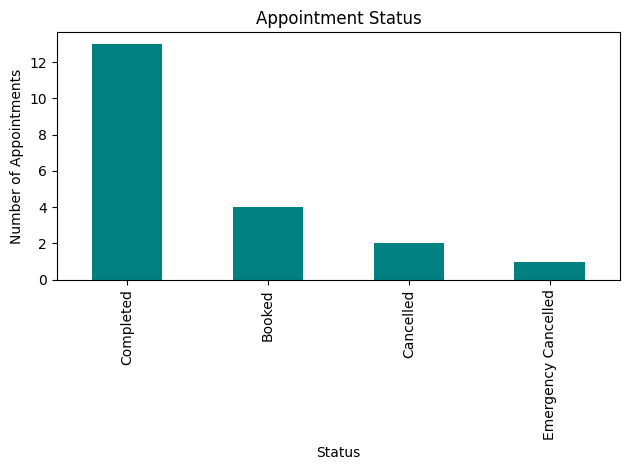

In [18]:
df["appointment_status"].value_counts().plot(
    kind="bar",
    color="teal"
)

plt.title("Appointment Status")
plt.xlabel("Status")
plt.ylabel("Number of Appointments")

plt.tight_layout()
plt.show()

### Insight

The appointment status analysis shows the number of completed, booked, cancelled, and emergency-cancelled appointments. This helps the hospital understand appointment utilization and cancellation patterns.

In [19]:
df["waiting_time_minutes"].mean()

37.5

In [20]:
df.groupby(
    "department"
)["waiting_time_minutes"].mean()

department
Cardiology          40.625000
General Medicine    33.333333
Neurology           37.500000
Name: waiting_time_minutes, dtype: float64

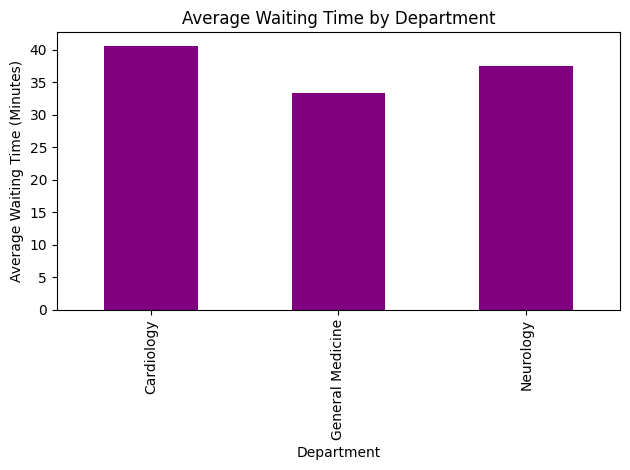

In [22]:
df.groupby(
    "department"
)["waiting_time_minutes"].mean().plot(
    kind="bar",
    color="purple"
)

plt.title("Average Waiting Time by Department")
plt.xlabel("Department")
plt.ylabel("Average Waiting Time (Minutes)")

plt.tight_layout()
plt.show()

### Insight

The department-wise waiting-time analysis helps identify departments where patients experience longer waiting periods. This information can help hospital management understand where operational improvements may be required.

## 5. Laboratory Analysis

Laboratory results can be analyzed to understand the distribution of test results and identify records that may require further attention.

In [23]:
df.groupby("lab_test")["lab_result"].mean()

lab_test
Blood Test      13.525000
Cholesterol    215.600000
Glucose        161.428571
Name: lab_result, dtype: float64

In [24]:
df["lab_test"].value_counts()

lab_test
Blood Test     8
Glucose        7
Cholesterol    5
Name: count, dtype: int64

In [25]:
df[[
    "patient_id",
    "lab_test",
    "lab_result",
    "diagnosis"
]]

,patient_id,lab_test,lab_result,diagnosis
0,1001,Blood Test,13.5,Routine Checkup
1,1002,Glucose,145.0,Diabetes
2,1003,Cholesterol,225.0,Hypertension
3,1004,Blood Test,14.1,Routine Checkup
4,1005,Glucose,168.0,Diabetes
5,1006,Blood Test,12.8,Migraine
6,1007,Cholesterol,210.0,High Cholesterol
7,1008,Glucose,155.0,Hypertension
8,1009,Blood Test,15.0,Routine Checkup
9,1010,Glucose,172.0,Diabetes


## 6. Wearable Health Data Analysis

Wearable devices continuously generate health measurements. In this dataset, heart rate and SpO2 are used as examples of wearable measurements.

In a real system, this type of data could be processed using a streaming pipeline.

In [26]:
df[[
    "patient_id",
    "heart_rate",
    "spo2"
]].head()

,patient_id,heart_rate,spo2
0,1001,78,98
1,1002,92,97
2,1003,108,94
3,1004,82,99
4,1005,115,92


In [27]:
df["heart_rate"].describe()

count     20.000000
mean      96.650000
std       13.861249
min       76.000000
25%       83.500000
50%       98.000000
75%      108.250000
max      118.000000
Name: heart_rate, dtype: float64

In [28]:
df["spo2"].describe()

count    20.000000
mean     95.300000
std       2.939746
min      90.000000
25%      93.000000
50%      95.500000
75%      98.000000
max      99.000000
Name: spo2, dtype: float64

In [29]:
high_heart_rate = df[df["heart_rate"] > 100]

high_heart_rate[[
    "patient_id",
    "heart_rate",
    "spo2"
]]

,patient_id,heart_rate,spo2
2,1003,108,94
4,1005,115,92
7,1008,104,93
9,1010,112,91
11,1012,106,94
12,1013,118,90
14,1015,110,93
16,1017,107,92
18,1019,101,95
19,1020,109,93


In [30]:
low_spo2 = df[df["spo2"] < 95]

low_spo2[[
    "patient_id",
    "heart_rate",
    "spo2"
]]

,patient_id,heart_rate,spo2
2,1003,108,94
4,1005,115,92
7,1008,104,93
9,1010,112,91
11,1012,106,94
12,1013,118,90
14,1015,110,93
16,1017,107,92
19,1020,109,93


## 7. High-Risk Patient Identification

The integrated patient data can be used as input for identifying patients who may require additional attention.

For this demonstration, a simple rule-based risk score is created using age, heart rate, and SpO2. In a real hospital environment, a properly validated machine-learning model would be required.

In [31]:
df["risk_score"] = 0

In [32]:
df.loc[df["age"] >= 60, "risk_score"] += 1

In [33]:
df.loc[df["heart_rate"] > 100, "risk_score"] += 1

In [34]:
df.loc[df["spo2"] < 95, "risk_score"] += 1

In [35]:
df["risk_level"] = "Low"

df.loc[
    df["risk_score"] == 1,
    "risk_level"
] = "Medium"

df.loc[
    df["risk_score"] >= 2,
    "risk_level"
] = "High"

In [36]:
df[[
    "patient_id",
    "age",
    "heart_rate",
    "spo2",
    "risk_score",
    "risk_level"
]]

,patient_id,age,heart_rate,spo2,risk_score,risk_level
0,1001,25,78,98,0,Low
1,1002,34,92,97,0,Low
2,1003,67,108,94,3,High
3,1004,29,82,99,0,Low
4,1005,72,115,92,3,High
5,1006,55,88,96,0,Low
6,1007,41,95,98,0,Low
7,1008,63,104,93,3,High
8,1009,31,76,99,0,Low
9,1010,69,112,91,3,High


In [37]:
df[df["appointment_status"] == "Emergency Cancelled"]

,patient_id,patient_name,age,gender,department,doctor,appointment_date,scheduled_time,actual_consultation_time,appointment_status,lab_test,lab_result,spo2,heart_rate,diagnosis,waiting_time_minutes,risk_score,risk_level
11,1012,Isha,58,F,General Medicine,Dr. Kumar,2026-09-21,2026-09-21 11:10:00,2026-09-21 11:45:00,Emergency Cancelled,Blood Test,11.9,94,106,Hypertension,35.0,2,High


In [38]:
df["appointment_status"].value_counts()

appointment_status
Completed              13
Booked                  4
Cancelled               2
Emergency Cancelled     1
Name: count, dtype: int64

## 8. Emergency Cancellation Analysis

Emergency cancellation is treated as an appointment event. When an emergency cancellation occurs, the affected appointment must be identified and the patient should be informed.

In a real application, the workflow would update the slot status, notify the affected patient, and provide alternative slots for rescheduling.

In [39]:
df["doctor"].value_counts()

doctor
Dr. Rao      8
Dr. Mehta    6
Dr. Kumar    6
Name: count, dtype: int64

In [40]:
df.groupby("doctor")["appointment_status"].count()

doctor
Dr. Kumar    6
Dr. Mehta    6
Dr. Rao      8
Name: appointment_status, dtype: int64

In [41]:
total_patients = df["patient_id"].nunique()

total_appointments = len(df)

completed = (
    df["appointment_status"] == "Completed"
).sum()

cancelled = (
    df["appointment_status"].isin(
        ["Cancelled", "Emergency Cancelled"]
    )
).sum()

average_waiting_time = (
    df["waiting_time_minutes"].mean()
)

high_risk_patients = (
    df["risk_level"] == "High"
).sum()

print("Total Patients:", total_patients)
print("Total Appointments:", total_appointments)
print("Completed Appointments:", completed)
print("Cancelled Appointments:", cancelled)
print("Average Waiting Time:", round(average_waiting_time, 2), "minutes")
print("High-Risk Patients:", high_risk_patients)

Total Patients: 20
Total Appointments: 20
Completed Appointments: 13
Cancelled Appointments: 3
Average Waiting Time: 37.5 minutes
High-Risk Patients: 9


## 9. Final Conclusion

The hospital dataset was loaded, inspected, cleaned, transformed, and analyzed.

The analysis covered:

- Appointment status
- Department-wise waiting time
- Laboratory results
- Wearable health measurements
- Emergency cancellations
- Patient risk levels

The pipeline demonstrates how hospital data from different operational areas can be processed and transformed into useful information for hospital management.

In a production environment, the same approach can be extended using batch and streaming ingestion, a raw data repository, a data warehouse, automated monitoring, and a validated machine-learning model for high-risk patient prediction.